In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns

import statsmodels.api as sm

# Алгоритм K-means
from sklearn.cluster import KMeans

# Алгоритм иерархической (аггломеративной) кластеризации
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Алгоритм DBSCAN
from sklearn.cluster import DBSCAN

# Метрики качества
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Масштабирование
from sklearn.preprocessing import StandardScaler

In [23]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

# 1. Пример алгоритма K-means

In [3]:
X = np.array([
    [7, 5],
    [5, 7],
    [7, 7],
    [3, 3],
    [4, 6],
    [1, 4],
    [1, 1],
    [2, 2],
    [8, 7],
    [6, 8],
    [5, 5],
    [3, 7]
])

data = pd.DataFrame(X, index = range(12))
data.columns = ['Visits', 'Bill']
data.T

,0,1,2,3,4,5,6,7,8,9,10,11
Visits,7,5,7,3,4,1,1,2,8,6,5,3
Bill,5,7,7,3,6,4,1,2,7,8,5,7


Изображаем точечную диаграмму с наблюдениями

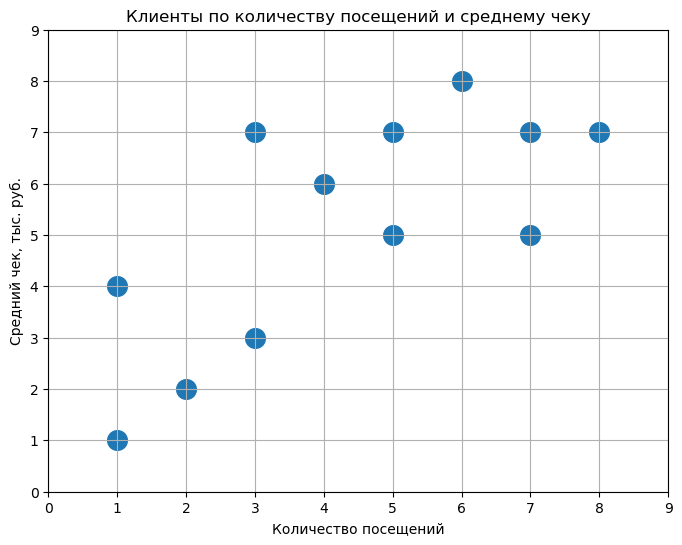

In [4]:
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(data['Visits'], data['Bill'], s = 200)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

Итерация 1: берем произвольные центроиды и считаем расстояния до всех наблюдений

In [6]:
iter1 = data.copy()
centr1 = iter1.iloc[4]
centr2 = iter1.iloc[10]
iter1['Centroid 1 distance'] = np.round(np.sqrt(np.sum((iter1[['Visits', 'Bill']] - centr1)**2, axis = 1)),2)
iter1['Centroid 2 distance'] = np.round(np.sqrt(np.sum((iter1[['Visits', 'Bill']] - centr2)**2, axis = 1)),2)
iter1['Cluster'] = np.where(iter1['Centroid 1 distance'] < iter1['Centroid 2 distance'], 'C1', 'C2')
iter1

,Visits,Bill,Centroid 1 distance,Centroid 2 distance,Cluster
0,7,5,3.16,2.00,C2
1,5,7,1.41,2.00,C1
2,7,7,3.16,2.83,C2
3,3,3,3.16,2.83,C2
4,4,6,0.00,1.41,C1
5,1,4,3.61,4.12,C1
6,1,1,5.83,5.66,C2
7,2,2,4.47,4.24,C2
8,8,7,4.12,3.61,C2
9,6,8,2.83,3.16,C1


Определяем кластеры и изображаем на графике

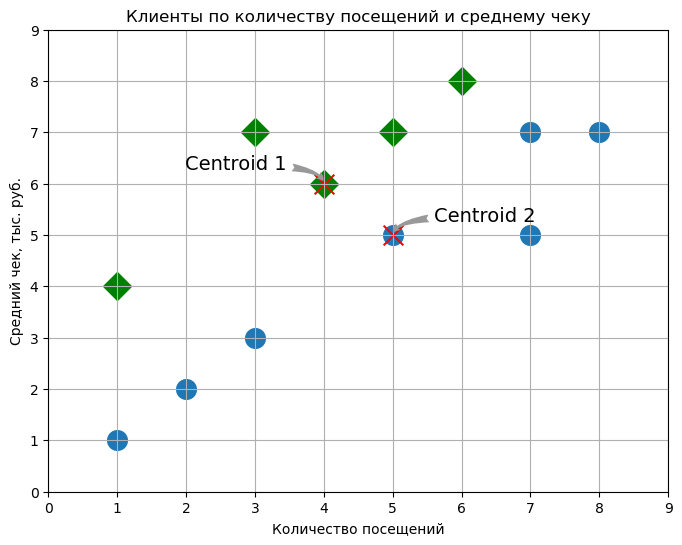

In [7]:
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(iter1[iter1['Cluster']=='C1']['Visits'], iter1[iter1['Cluster']=='C1']['Bill'], s = 200, marker = 'D', c = 'g')
ax.scatter(iter1[iter1['Cluster']=='C2']['Visits'], iter1[iter1['Cluster']=='C2']['Bill'], s = 200,)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
ax.scatter(centr1['Visits'], centr1['Bill'], s = 200, marker = 'x', c = 'r')
ax.scatter(centr2['Visits'], centr2['Bill'], s = 200, marker = 'x', c = 'r')
plt.grid(True)

el = Ellipse((2, -1), 0.5, 0.5)

ax.annotate(r'Centroid 1',
            xy=(centr1['Visits'], centr1['Bill']), xycoords='data',
            xytext=(-100, 10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))

ax.annotate(r'Centroid 2',
            xy=(centr2['Visits'], centr2['Bill']), xycoords='data',
            xytext=(30, 10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))


plt.show()

Считаем координаты новых центроидов

In [8]:
centr1 = iter1[iter1['Cluster']=='C1'][['Visits', 'Bill']].mean()
centr2 = iter1[iter1['Cluster']=='C2'][['Visits', 'Bill']].mean()
print("Координаты нового центроида для 1 группы:\n", centr1.values[0], " ", centr1.values[1])
print("Координаты нового центроида для 2 группы:\n", centr2.values[0], " ", centr2.values[1])

Координаты нового центроида для 1 группы:
 3.8   6.4
Координаты нового центроида для 2 группы:
 4.714285714285714   4.285714285714286


Изображаем центроиды на графике

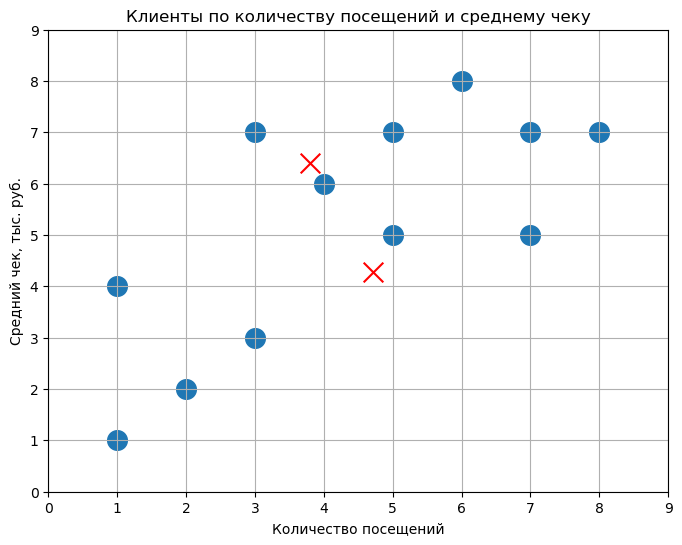

In [9]:
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(data['Visits'], data['Bill'], s = 200)
ax.scatter(centr1['Visits'], centr1['Bill'], s = 200, marker = 'x', c = 'r')
ax.scatter(centr2['Visits'], centr2['Bill'], s = 200, marker = 'x', c = 'r')
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

Итерация 2: берем новые центроиды и считаем расстояния до всех наблюдений

In [10]:
iter2 = data.copy()
iter2['Centroid 1 distance'] = np.round(np.sqrt(np.sum((iter2[['Visits', 'Bill']] - centr1)**2, axis = 1)),2)
iter2['Centroid 2 distance'] = np.round(np.sqrt(np.sum((iter2[['Visits', 'Bill']] - centr2)**2, axis = 1)),2)
iter2['Cluster'] = np.where(iter2['Centroid 1 distance'] < iter2['Centroid 2 distance'], 'C1', 'C2')
iter2

,Visits,Bill,Centroid 1 distance,Centroid 2 distance,Cluster
0,7,5,3.49,2.39,C2
1,5,7,1.34,2.73,C1
2,7,7,3.26,3.55,C1
3,3,3,3.49,2.14,C2
4,4,6,0.45,1.86,C1
5,1,4,3.69,3.73,C1
6,1,1,6.08,4.96,C2
7,2,2,4.75,3.55,C2
8,8,7,4.24,4.26,C1
9,6,8,2.72,3.93,C1


Определяем кластеры и изображаем на графике

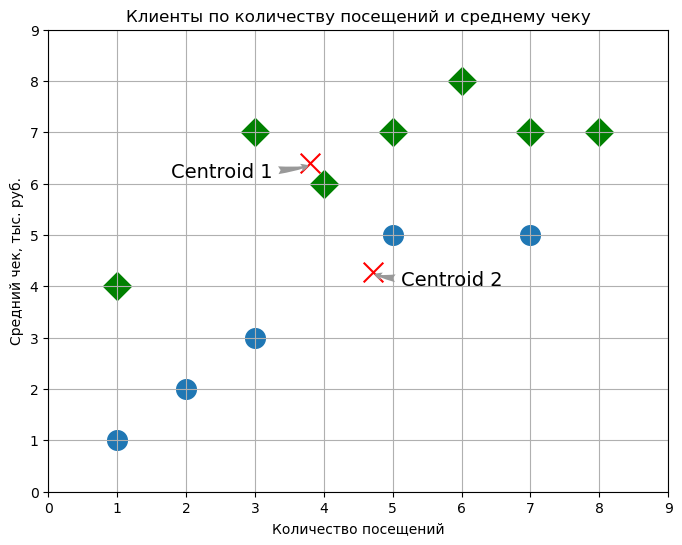

In [11]:
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(iter2[iter2['Cluster']=='C1']['Visits'], iter2[iter2['Cluster']=='C1']['Bill'], s = 200, marker = 'D', c = 'g')
ax.scatter(iter2[iter2['Cluster']=='C2']['Visits'], iter2[iter2['Cluster']=='C2']['Bill'], s = 200,)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
ax.scatter(centr1['Visits'], centr1['Bill'], s = 200, marker = 'x', c = 'r')
ax.scatter(centr2['Visits'], centr2['Bill'], s = 200, marker = 'x', c = 'r')
plt.grid(True)

el = Ellipse((2, -1), 0.5, 0.5)

ax.annotate(r'Centroid 1',
            xy=(centr1['Visits'], centr1['Bill']), xycoords='data',
            xytext=(-100, -10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))

ax.annotate(r'Centroid 2',
            xy=(centr2['Visits'], centr2['Bill']), xycoords='data',
            xytext=(20, -10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))


plt.show()

Смотрим, изменилась ли принадлежность наблюдений к кластерам

In [12]:
compare = data.copy()
compare['Iteration 1'] = iter1['Cluster']
compare['Iteration 2'] = iter2['Cluster']
compare['Changed?'] = np.where(compare['Iteration 1'] == compare['Iteration 2'], 'No', 'Yes')
compare

,Visits,Bill,Iteration 1,Iteration 2,Changed?
0,7,5,C2,C2,No
1,5,7,C1,C1,No
2,7,7,C2,C1,Yes
3,3,3,C2,C2,No
4,4,6,C1,C1,No
5,1,4,C1,C1,No
6,1,1,C2,C2,No
7,2,2,C2,C2,No
8,8,7,C2,C1,Yes
9,6,8,C1,C1,No


Итерация 3: берем новые центроиды и считаем расстояния до всех наблюдений

In [13]:
iter3 = data.copy()
centr1 = iter2[iter2['Cluster']=='C1'][['Visits', 'Bill']].mean()
centr2 = iter2[iter2['Cluster']=='C2'][['Visits', 'Bill']].mean()
iter3['Centroid 1 distance'] = np.round(np.sqrt(np.sum((iter3[['Visits', 'Bill']] - centr1)**2, axis = 1)),2)
iter3['Centroid 2 distance'] = np.round(np.sqrt(np.sum((iter3[['Visits', 'Bill']] - centr2)**2, axis = 1)),2)
iter3['Cluster'] = np.where(iter3['Centroid 1 distance'] < iter3['Centroid 2 distance'], 'C1', 'C2')
iter3

,Visits,Bill,Centroid 1 distance,Centroid 2 distance,Cluster
0,7,5,2.66,3.85,C1
1,5,7,0.45,4.05,C1
2,7,7,2.19,5.10,C1
3,3,3,4.03,0.63,C2
4,4,6,1.03,2.83,C1
5,1,4,4.64,2.72,C2
6,1,1,6.78,3.41,C2
7,2,2,5.39,2.00,C2
8,8,7,3.17,5.81,C1
9,6,8,1.83,5.37,C1


Определяем кластеры и изображаем на графике

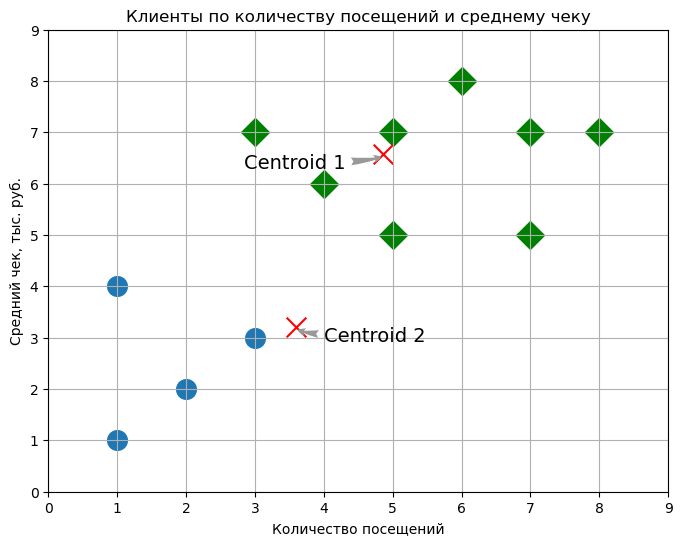

In [14]:
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(iter3[iter3['Cluster']=='C1']['Visits'], iter3[iter3['Cluster']=='C1']['Bill'], s = 200, marker = 'D', c = 'g')
ax.scatter(iter3[iter3['Cluster']=='C2']['Visits'], iter3[iter3['Cluster']=='C2']['Bill'], s = 200,)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
ax.scatter(centr1['Visits'], centr1['Bill'], s = 200, marker = 'x', c = 'r')
ax.scatter(centr2['Visits'], centr2['Bill'], s = 200, marker = 'x', c = 'r')
plt.grid(True)

el = Ellipse((2, -1), 0.5, 0.5)

ax.annotate(r'Centroid 1',
            xy=(centr1['Visits'], centr1['Bill']), xycoords='data',
            xytext=(-100, -10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))

ax.annotate(r'Centroid 2',
            xy=(centr2['Visits'], centr2['Bill']), xycoords='data',
            xytext=(20, -10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))


plt.show()

Смотрим, изменилась ли принадлежность наблюдений к кластерам

In [16]:
compare = data.copy()
compare['Iteration 2'] = iter2['Cluster']
compare['Iteration 3'] = iter3['Cluster']
compare['Changed?'] = np.where(compare['Iteration 2'] == compare['Iteration 3'], 'No', 'Yes')
compare

,Visits,Bill,Iteration 2,Iteration 3,Changed?
0,7,5,C2,C1,Yes
1,5,7,C1,C1,No
2,7,7,C1,C1,No
3,3,3,C2,C2,No
4,4,6,C1,C1,No
5,1,4,C1,C2,Yes
6,1,1,C2,C2,No
7,2,2,C2,C2,No
8,8,7,C1,C1,No
9,6,8,C1,C1,No


Итерация 4: берем новые центроиды и считаем расстояния до всех наблюдений

In [17]:
iter4 = data.copy()
centr1 = iter3[iter3['Cluster']=='C1'][['Visits', 'Bill']].mean()
centr2 = iter3[iter3['Cluster']=='C2'][['Visits', 'Bill']].mean()
iter4['Centroid 1 distance'] = np.round(np.sqrt(np.sum((iter4[['Visits', 'Bill']] - centr1)**2, axis = 1)),2)
iter4['Centroid 2 distance'] = np.round(np.sqrt(np.sum((iter4[['Visits', 'Bill']] - centr2)**2, axis = 1)),2)
iter4['Cluster'] = np.where(iter4['Centroid 1 distance'] < iter4['Centroid 2 distance'], 'C1', 'C2')
iter4

,Visits,Bill,Centroid 1 distance,Centroid 2 distance,Cluster
0,7,5,2.03,5.81,C1
1,5,7,0.80,5.55,C1
2,7,7,1.46,6.91,C1
3,3,3,4.38,1.35,C2
4,4,6,1.70,4.16,C1
5,1,4,5.26,1.68,C2
6,1,1,7.19,1.68,C2
7,2,2,5.78,0.56,C2
8,8,7,2.43,7.70,C1
9,6,8,1.55,6.95,C1


Определяем кластеры и изображаем на графике

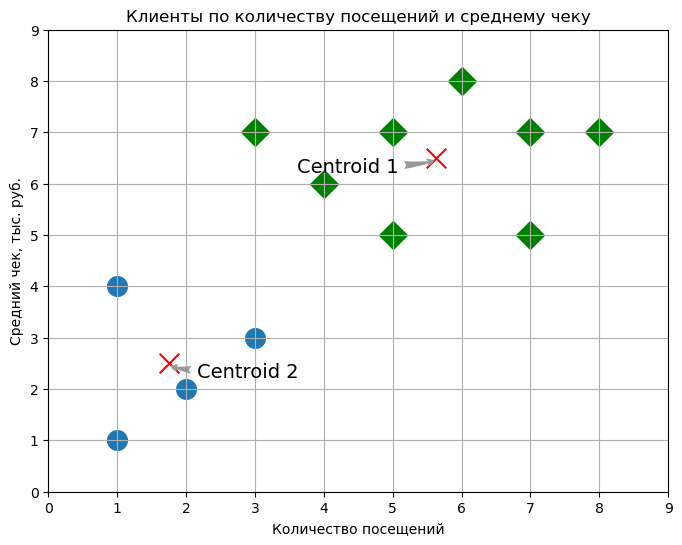

In [18]:
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(iter4[iter4['Cluster']=='C1']['Visits'], iter4[iter4['Cluster']=='C1']['Bill'], s = 200, marker = 'D', c = 'g')
ax.scatter(iter4[iter4['Cluster']=='C2']['Visits'], iter4[iter4['Cluster']=='C2']['Bill'], s = 200,)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
ax.scatter(centr1['Visits'], centr1['Bill'], s = 200, marker = 'x', c = 'r')
ax.scatter(centr2['Visits'], centr2['Bill'], s = 200, marker = 'x', c = 'r')
plt.grid(True)

el = Ellipse((2, -1), 0.5, 0.5)

ax.annotate(r'Centroid 1',
            xy=(centr1['Visits'], centr1['Bill']), xycoords='data',
            xytext=(-100, -10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))

ax.annotate(r'Centroid 2',
            xy=(centr2['Visits'], centr2['Bill']), xycoords='data',
            xytext=(20, -10), textcoords='offset points',
            size=14,
            arrowprops=dict(arrowstyle="fancy",
                            fc="0.6", ec="none",
                            patchB=el,
                            connectionstyle="angle3,angleA=0,angleB=-90"))


plt.show()

Смотрим, изменилась ли принадлежность наблюдений к кластерам

In [19]:
compare = data.copy()
compare['Iteration 3'] = iter3['Cluster']
compare['Iteration 4'] = iter4['Cluster']
compare['Changed?'] = np.where(compare['Iteration 3'] == compare['Iteration 4'], 'No', 'Yes')
compare

,Visits,Bill,Iteration 3,Iteration 4,Changed?
0,7,5,C1,C1,No
1,5,7,C1,C1,No
2,7,7,C1,C1,No
3,3,3,C2,C2,No
4,4,6,C1,C1,No
5,1,4,C2,C2,No
6,1,1,C2,C2,No
7,2,2,C2,C2,No
8,8,7,C1,C1,No
9,6,8,C1,C1,No


In [20]:
result = compare[['Visits', 'Bill', 'Iteration 4']]
result.columns = ['Visits', 'Bill', 'Cluster']
result

,Visits,Bill,Cluster
0,7,5,C1
1,5,7,C1
2,7,7,C1
3,3,3,C2
4,4,6,C1
5,1,4,C2
6,1,1,C2
7,2,2,C2
8,8,7,C1
9,6,8,C1


## 2. То же с использованием SKLEARN

In [24]:
kmeans = KMeans(n_clusters = 2)
kmeans.fit(data)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=2)

Получаем метки кластеров

In [25]:
print(kmeans.labels_)

[1 1 1 0 1 0 0 0 1 1 1 1]


In [28]:
data['labels'] = kmeans.labels_

In [29]:
data

,Visits,Bill,labels
0,7,5,0
1,5,7,0
2,7,7,0
3,3,3,1
4,4,6,0
5,1,4,1
6,1,1,1
7,2,2,1
8,8,7,0
9,6,8,0


Получаем координаты центроидов

In [30]:
print(centr1)

Visits    5.625
Bill      6.500
dtype: float64


In [31]:
print(centr2)

Visits    1.75
Bill      2.50
dtype: float64


То же в виде матрицы

In [32]:
print(kmeans.cluster_centers_)

[[5.625 6.5  ]
 [1.75  2.5  ]]


## 3. Выбор количества кластеров: метод локтя

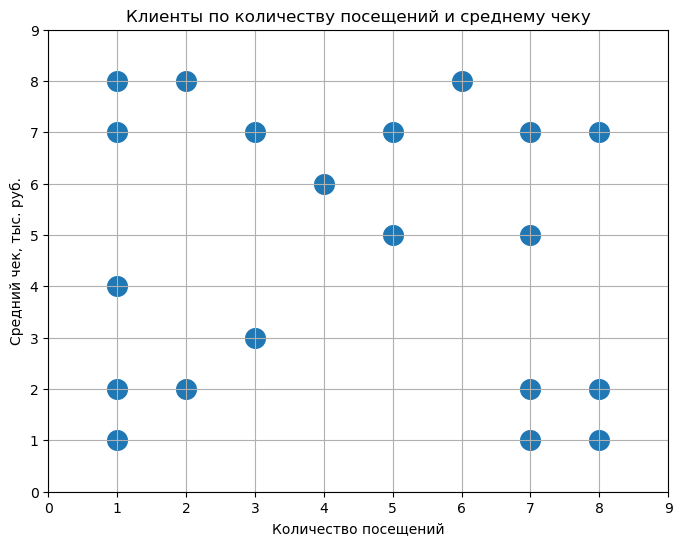

In [33]:
X = np.array([
    [7, 5],
    [5, 7],
    [7, 7],
    [3, 3],
    [4, 6],
    [1, 4],
    [1, 1],
    [2, 2],
    [8, 7],
    [6, 8],
    [5, 5],
    [3, 7],
    [1, 8],
    [2, 8],
    [1, 7],
    [8, 1],
    [8, 2],
    [7, 1],
    [7, 2],
    [1, 2]
])

data = pd.DataFrame(X)
data.columns = ['X', 'Y']
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(data['X'], data['Y'], s = 200)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

In [34]:
K = range(2,6)
meanDispersions = []

for i, k in enumerate(K):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(data)
    data[f'Cluster k={k}'] = kmeans.labels_

C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when

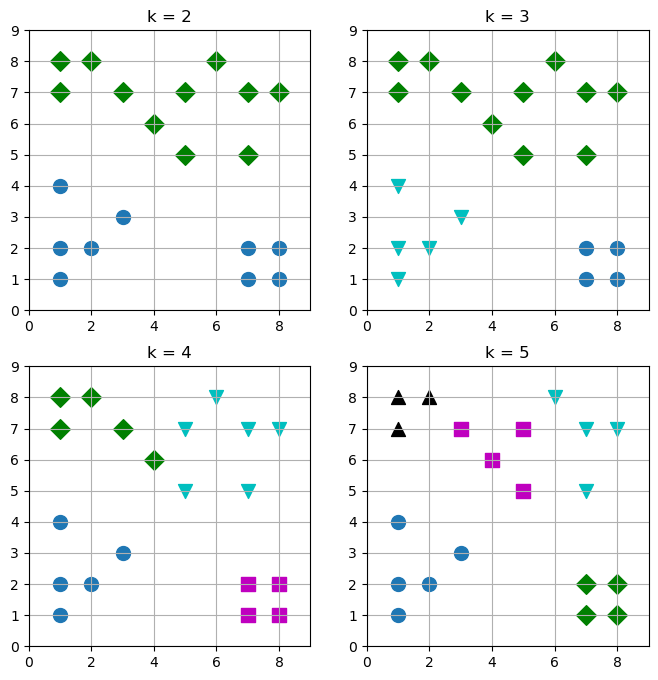

In [35]:
fig, ax = plt.subplots(2,2, figsize = (8,8))

# For k=2
ax[0,0].scatter(data[data['Cluster k=2']==0]['X'], data[data['Cluster k=2']==0]['Y'], s = 100, marker = 'D', c = 'g')
ax[0,0].scatter(data[data['Cluster k=2']==1]['X'], data[data['Cluster k=2']==1]['Y'], s = 100,)
ax[0,0].set_xlim(0,9)
ax[0,0].set_ylim(0,9)
ax[0,0].set_title('k = 2')
ax[0,0].grid(True)

# For k=3
ax[0,1].scatter(data[data['Cluster k=3']==1]['X'], data[data['Cluster k=3']==1]['Y'], s = 100, marker = 'D', c = 'g')
ax[0,1].scatter(data[data['Cluster k=3']==2]['X'], data[data['Cluster k=3']==2]['Y'], s = 100,)
ax[0,1].scatter(data[data['Cluster k=3']==0]['X'], data[data['Cluster k=3']==0]['Y'], s = 100, marker = 'v', c = 'c')
ax[0,1].set_xlim(0,9)
ax[0,1].set_ylim(0,9)
ax[0,1].set_title('k = 3')
ax[0,1].grid(True)

# For k=4
ax[1,0].scatter(data[data['Cluster k=4']==2]['X'], data[data['Cluster k=4']==2]['Y'], s = 100, marker = 'D', c = 'g')
ax[1,0].scatter(data[data['Cluster k=4']==0]['X'], data[data['Cluster k=4']==0]['Y'], s = 100)
ax[1,0].scatter(data[data['Cluster k=4']==3]['X'], data[data['Cluster k=4']==3]['Y'], s = 100, marker = 'v', c = 'c')
ax[1,0].scatter(data[data['Cluster k=4']==1]['X'], data[data['Cluster k=4']==1]['Y'], s = 100, marker = 's', c = 'm')
ax[1,0].set_xlim(0,9)
ax[1,0].set_ylim(0,9)
ax[1,0].set_title('k = 4')
ax[1,0].grid(True)

# For k=5
ax[1,1].scatter(data[data['Cluster k=5']==1]['X'], data[data['Cluster k=5']==1]['Y'], s = 100, marker = 'D', c = 'g')
ax[1,1].scatter(data[data['Cluster k=5']==3]['X'], data[data['Cluster k=5']==3]['Y'], s = 100)
ax[1,1].scatter(data[data['Cluster k=5']==2]['X'], data[data['Cluster k=5']==2]['Y'], s = 100, marker = 'v', c = 'c')
ax[1,1].scatter(data[data['Cluster k=5']==4]['X'], data[data['Cluster k=5']==4]['Y'], s = 100, marker = 's', c = 'm')
ax[1,1].scatter(data[data['Cluster k=5']==0]['X'], data[data['Cluster k=5']==0]['Y'], s = 100, marker = '^', c = 'k')
ax[1,1].set_xlim(0,9)
ax[1,1].set_ylim(0,9)
ax[1,1].set_title('k = 5')
ax[1,1].grid(True)

C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when

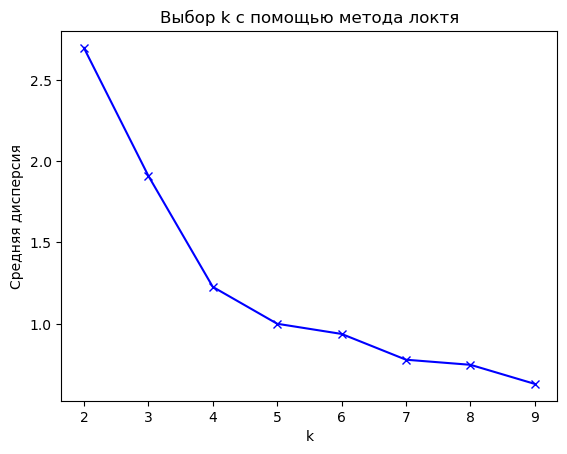

In [36]:
K = range(2,10)
meanDispersions = []

for k in K:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X)
    meanDispersions.append(sum(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis = 1))/X.shape[0])

plt.plot(K, meanDispersions, 'bx-')
plt.xlabel('k')
plt.ylabel('Средняя дисперсия')
plt.title('Выбор k с помощью метода локтя')
plt.show()

# 4. Выбор количества кластеров: Silhouette score

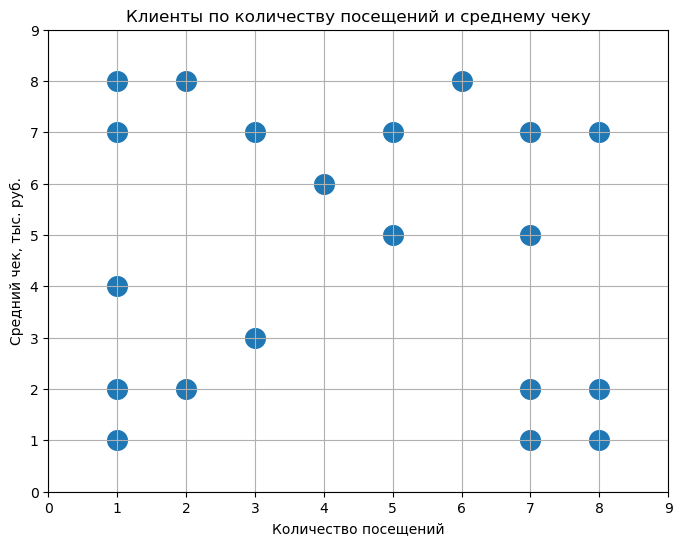

In [40]:
X = np.array([
    [7, 5],
    [5, 7],
    [7, 7],
    [3, 3],
    [4, 6],
    [1, 4],
    [1, 1],
    [2, 2],
    [8, 7],
    [6, 8],
    [5, 5],
    [3, 7],
    [1, 8],
    [2, 8],
    [1, 7],
    [8, 1],
    [8, 2],
    [7, 1],
    [7, 2],
    [1, 2]
])


data = pd.DataFrame(X)
data.columns = ['X', 'Y']
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(data['X'], data['Y'], s = 200)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\D\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when

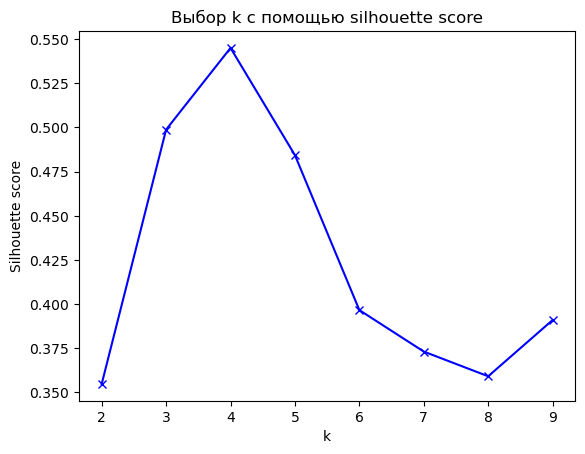

In [37]:
K = range(2,10)
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Выбор k с помощью silhouette score')
plt.show()

# 5. Аггломеративная кластеризация

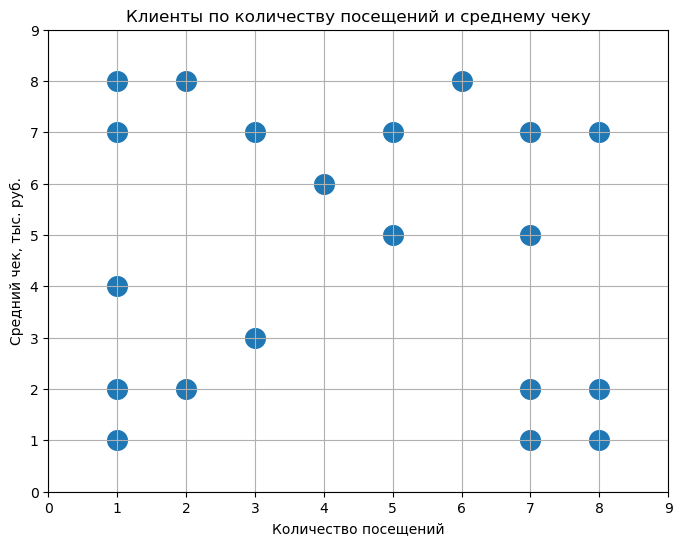

In [42]:
X = np.array([
    [7, 5],
    [5, 7],
    [7, 7],
    [3, 3],
    [4, 6],
    [1, 4],
    [1, 1],
    [2, 2],
    [8, 7],
    [6, 8],
    [5, 5],
    [3, 7],
    [1, 8],
    [2, 8],
    [1, 7],
    [8, 1],
    [8, 2],
    [7, 1],
    [7, 2],
    [1, 2]
])

data = pd.DataFrame(X)
data.columns = ['X', 'Y']
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(data['X'], data['Y'], s = 200)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

Расчет расстояния между кластерами по одиночной связи

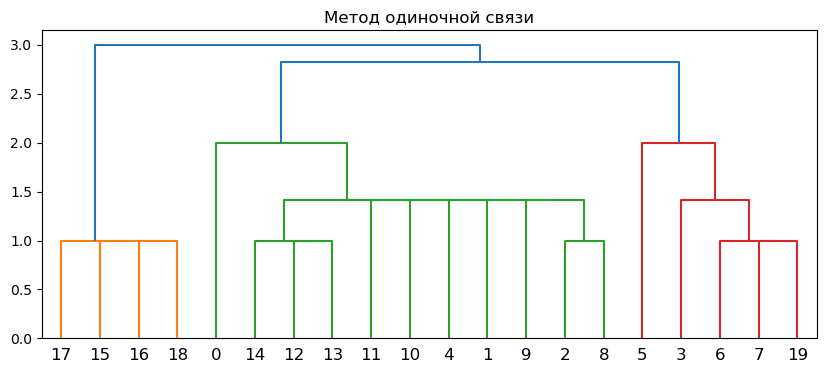

In [39]:
Y = linkage(data, 'single')
fig, ax = plt.subplots(figsize = (10,4))
plt.title("Метод одиночной связи")
dendr = dendrogram(Y, orientation = 'top')
plt.show()

In [43]:
n_clust = len(set(dendr['leaves_color_list']))
print("Рекомендуемое количество кластеров : ", n_clust)

Рекомендуемое количество кластеров :  3


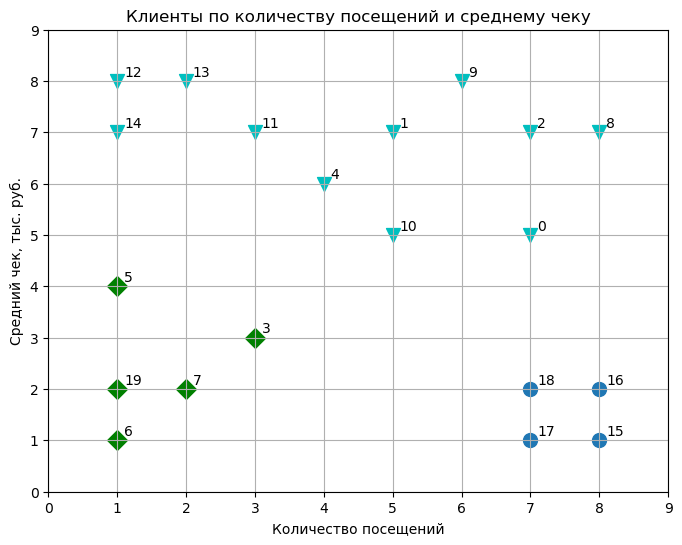

In [44]:
hclust = AgglomerativeClustering(n_clusters = n_clust, linkage = 'single').fit(data)
data['cluster_single'] = hclust.labels_

fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')
ax.scatter(data[data['cluster_single']==0]['X'], data[data['cluster_single']==0]['Y'], s = 100, marker = 'D', c = 'g')
ax.scatter(data[data['cluster_single']==1]['X'], data[data['cluster_single']==1]['Y'], s = 100,)
ax.scatter(data[data['cluster_single']==2]['X'], data[data['cluster_single']==2]['Y'], s = 100, marker = 'v', c = 'c')
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
for i in range(len(data)):
  ax.text(x = data.loc[i, 'X']+0.1, y = data.loc[i, 'Y']+0.1, s = i)
plt.show()

Расчет расстояния между кластерами по полной связи

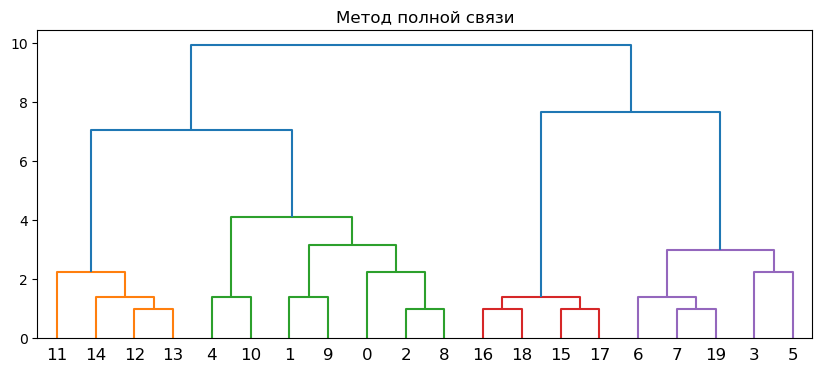

In [48]:
Y = linkage(data, 'complete')
fig, ax = plt.subplots(figsize = (10,4))
plt.title("Метод полной связи")
dendr = dendrogram(Y, orientation = 'top')
plt.show()

In [49]:
n_clust = len(set(dendr['leaves_color_list']))
print("Рекомендуемое количество кластеров : ", n_clust)

Рекомендуемое количество кластеров :  4


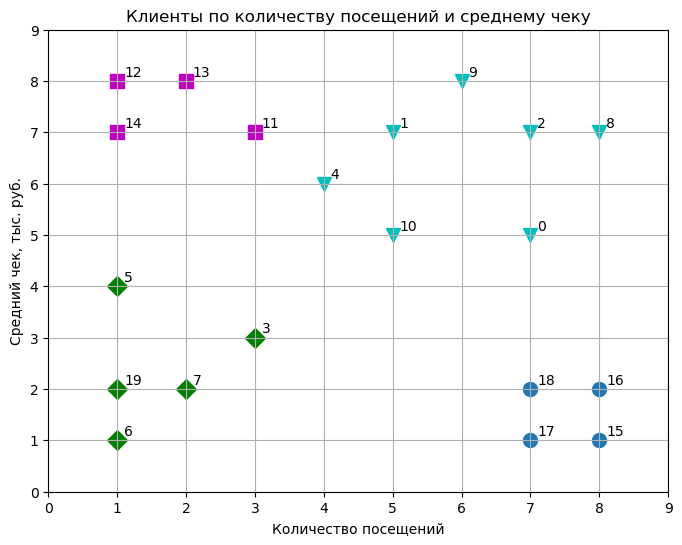

In [50]:
hclust = AgglomerativeClustering(n_clusters = 4, linkage = 'complete').fit(data)
data['cluster_complete'] = hclust.labels_

fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')
ax.scatter(data[data['cluster_complete']==0]['X'], data[data['cluster_complete']==0]['Y'], s = 100, marker = 'v', c = 'c')
ax.scatter(data[data['cluster_complete']==1]['X'], data[data['cluster_complete']==1]['Y'], s = 100, marker = 'D', c = 'g')
ax.scatter(data[data['cluster_complete']==2]['X'], data[data['cluster_complete']==2]['Y'], s = 100, )
ax.scatter(data[data['cluster_complete']==3]['X'], data[data['cluster_complete']==3]['Y'], s = 100, marker = 's', c = 'm')
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
for i in range(len(data)):
  ax.text(x = data.loc[i, 'X']+0.1, y = data.loc[i, 'Y']+0.1, s = i)
plt.show()

Расчет расстояния между кластерами по среднему расстоянию

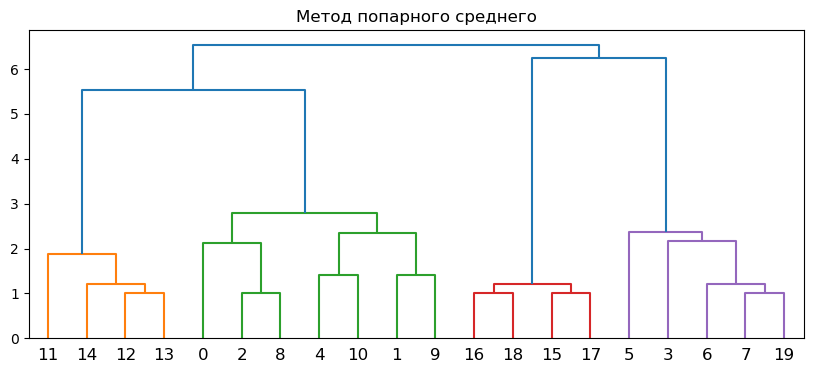

In [51]:
Y = linkage(data, 'average')
fig, ax = plt.subplots(figsize = (10,4))
plt.title("Метод попарного среднего")
dendr = dendrogram(Y, orientation = 'top')
plt.show()

In [52]:
n_clust = len(set(dendr['leaves_color_list']))
print("Рекомендуемое количество кластеров : ", n_clust)

Рекомендуемое количество кластеров :  4


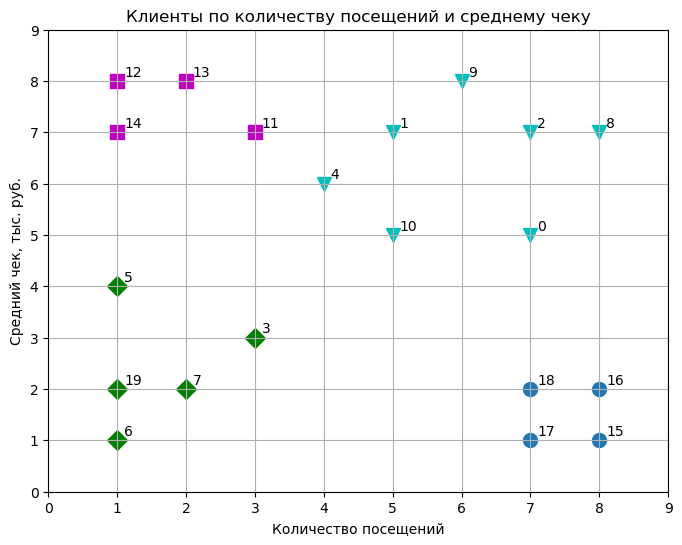

In [53]:
hclust = AgglomerativeClustering(n_clusters = n_clust, linkage = 'average').fit(data)
data['cluster_average'] = hclust.labels_

fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')
ax.scatter(data[data['cluster_average']==0]['X'], data[data['cluster_average']==0]['Y'], s = 100, marker = 'v', c = 'c')
ax.scatter(data[data['cluster_average']==1]['X'], data[data['cluster_average']==1]['Y'], s = 100, marker = 'D', c = 'g')
ax.scatter(data[data['cluster_average']==2]['X'], data[data['cluster_average']==2]['Y'], s = 100, )
ax.scatter(data[data['cluster_average']==3]['X'], data[data['cluster_average']==3]['Y'], s = 100, marker = 's', c = 'm')
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
for i in range(len(data)):
  ax.text(x = data.loc[i, 'X']+0.1, y = data.loc[i, 'Y']+0.1, s = i)
plt.show()

Расчет расстояния между кластерами по методу Уорда

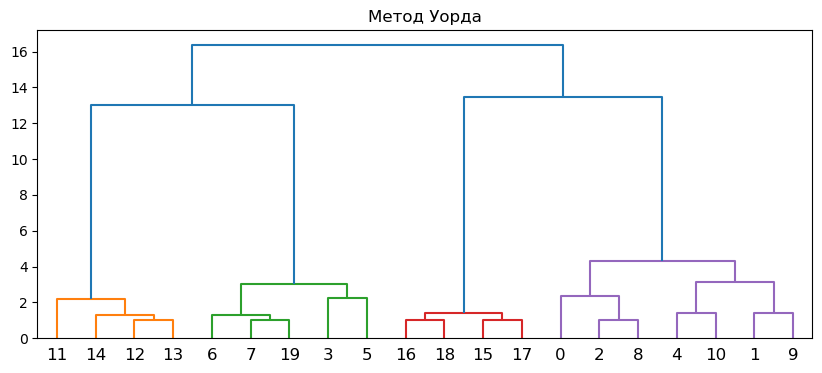

In [54]:
Y = linkage(data, 'ward')
fig, ax = plt.subplots(figsize = (10,4))
plt.title("Метод Уорда")
dendr = dendrogram(Y, orientation = 'top')
plt.show()

In [ ]:
n_clust = len(set(dendr['leaves_color_list']))
print("Рекомендуемое количество кластеров : ", n_clust)

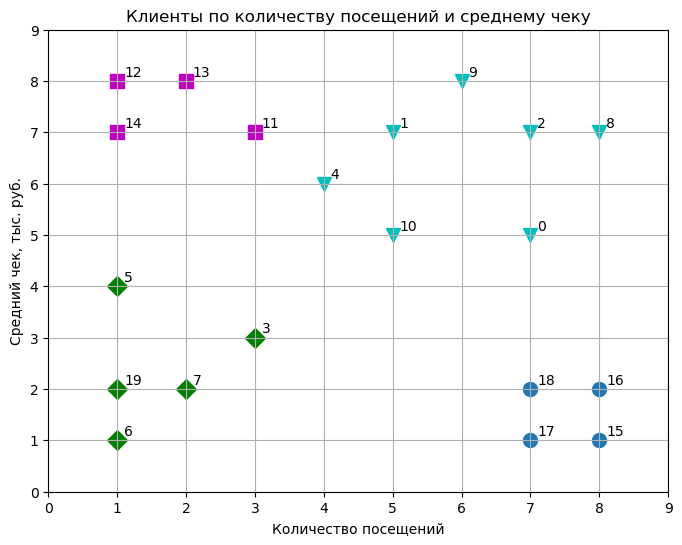

In [55]:
hclust = AgglomerativeClustering(n_clusters = 4, linkage = 'ward').fit(data)
data['cluster_ward'] = hclust.labels_

fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')
ax.scatter(data[data['cluster_ward']==0]['X'], data[data['cluster_ward']==0]['Y'], s = 100, marker = 'v', c = 'c')
ax.scatter(data[data['cluster_ward']==1]['X'], data[data['cluster_ward']==1]['Y'], s = 100, marker = 'D', c = 'g')
ax.scatter(data[data['cluster_ward']==2]['X'], data[data['cluster_ward']==2]['Y'], s = 100, )
ax.scatter(data[data['cluster_ward']==3]['X'], data[data['cluster_ward']==3]['Y'], s = 100, marker = 's', c = 'm')
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
for i in range(len(data)):
  ax.text(x = data.loc[i, 'X']+0.1, y = data.loc[i, 'Y']+0.1, s = i)
plt.show()

# 6. Алгоритм DBSCAN

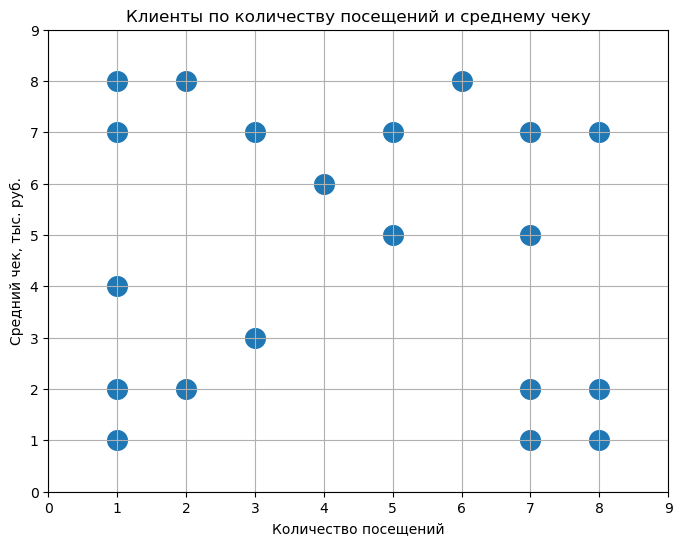

In [56]:
X = np.array([
    [7, 5],
    [5, 7],
    [7, 7],
    [3, 3],
    [4, 6],
    [1, 4],
    [1, 1],
    [2, 2],
    [8, 7],
    [6, 8],
    [5, 5],
    [3, 7],
    [1, 8],
    [2, 8],
    [1, 7],
    [8, 1],
    [8, 2],
    [7, 1],
    [7, 2],
    [1, 2]
])

data = pd.DataFrame(X)
data.columns = ['X', 'Y']
fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')

ax.scatter(data['X'], data['Y'], s = 200)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

Радиус 1.5

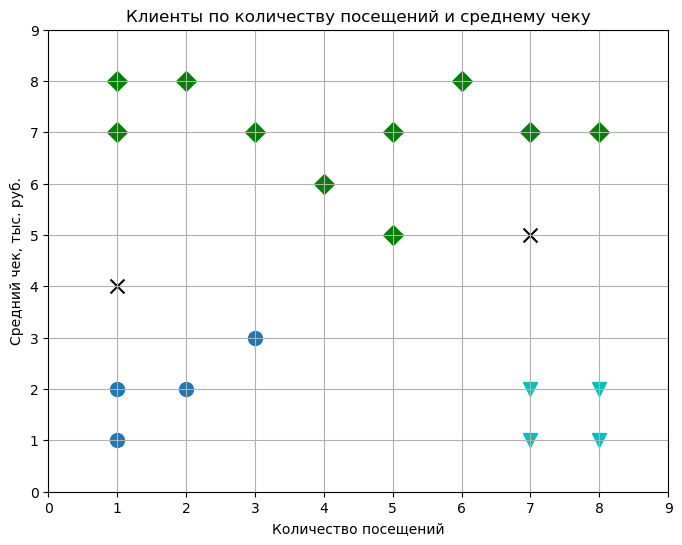

In [57]:
dbsc = DBSCAN(eps = 1.5, min_samples = 2).fit(data)

data['cluster_single'] = dbsc.labels_

fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')
ax.scatter(data[data['cluster_single']==0]['X'], data[data['cluster_single']==0]['Y'], s = 100, marker = 'D', c = 'g')
ax.scatter(data[data['cluster_single']==1]['X'], data[data['cluster_single']==1]['Y'], s = 100,)
ax.scatter(data[data['cluster_single']==2]['X'], data[data['cluster_single']==2]['Y'], s = 100, marker = 'v', c = 'c')
ax.scatter(data[data['cluster_single']==-1]['X'], data[data['cluster_single']==-1]['Y'], s = 100, marker = 'x', c = 'black')
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

Радиус 3

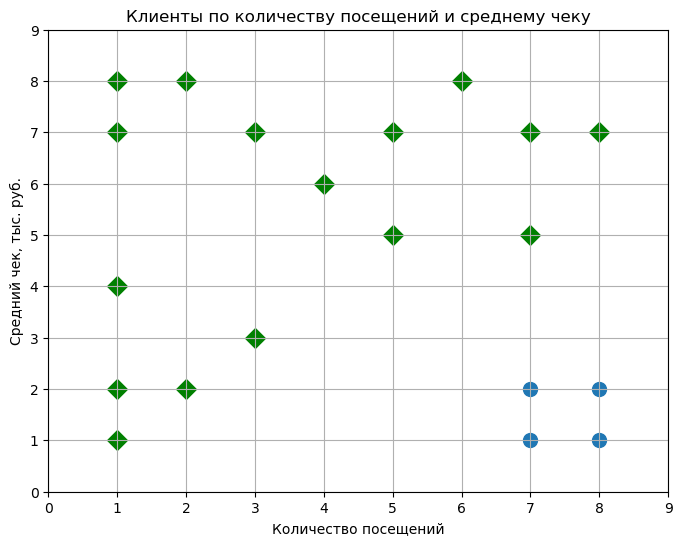

In [58]:
dbsc = DBSCAN(eps = 3, min_samples = 2).fit(data)

data['cluster_single'] = dbsc.labels_

fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')
ax.scatter(data[data['cluster_single']==0]['X'], data[data['cluster_single']==0]['Y'], s = 100, marker = 'D', c = 'g')
ax.scatter(data[data['cluster_single']==1]['X'], data[data['cluster_single']==1]['Y'], s = 100,)
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

Минимальное количество наблюдений = 5 и радиус 2.5

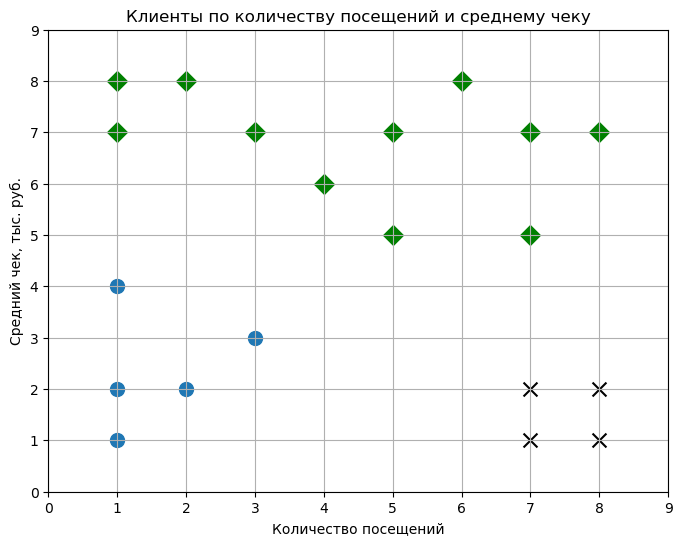

In [59]:
dbsc = DBSCAN(eps = 2.5, min_samples = 5).fit(data)

data['cluster_single'] = dbsc.labels_

fig, ax = plt.subplots(figsize = (8,6))
plt.title('Клиенты по количеству посещений и среднему чеку')
plt.xlabel('Количество посещений')
plt.ylabel('Средний чек, тыс. руб.')
ax.scatter(data[data['cluster_single']==0]['X'], data[data['cluster_single']==0]['Y'], s = 100, marker = 'D', c = 'g')
ax.scatter(data[data['cluster_single']==1]['X'], data[data['cluster_single']==1]['Y'], s = 100,)
# ax.scatter(data[data['cluster_single']==2]['X'], data[data['cluster_single']==2]['Y'], s = 100, marker = 'v', c = 'c')
ax.scatter(data[data['cluster_single']==-1]['X'], data[data['cluster_single']==-1]['Y'], s = 100, marker = 'x', c = 'black')
ax.set_xlim(0,9)
ax.set_ylim(0,9)
plt.grid(True)
plt.show()

# 7. Практический пример

In [61]:
df = sm.datasets.get_rdataset("mlc_churn", 'modeldata').data
df["total_charge"] = df[[col for col in df.columns if col.find("charge")!= -1]].sum(axis = 1)
df.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,...,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn,total_charge
0,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,...,16.78,244.7,91,11.01,10.0,3,2.70,1,no,75.56
1,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,...,16.62,254.4,103,11.45,13.7,3,3.70,1,no,59.24
2,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,...,10.30,162.6,104,7.32,12.2,5,3.29,0,no,62.29
3,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,...,5.26,196.9,89,8.86,6.6,7,1.78,2,no,66.80
4,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,...,12.61,186.9,121,8.41,10.1,3,2.73,3,no,52.09


In [62]:
features_col = ["total_charge", "number_customer_service_calls"]
X = df[features_col]

In [69]:
def plot_clusters(df, cluster_col):
    fig, ax = plt.subplots(1,1, figsize = (10, 5))
    sns.scatterplot(x = "number_customer_service_calls", y = "total_charge", data = df, hue = cluster_col, ax = ax)
    ax.set_xlabel("Количество звонков в поддержку")
    ax.set_ylabel("Суммарные расходы")
    plt.show()

### K-means

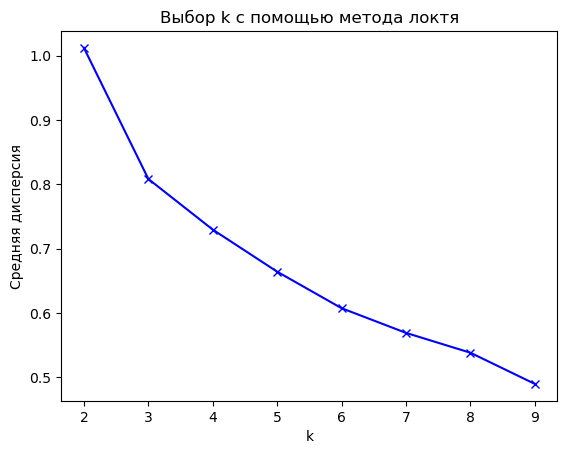

In [64]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
K = range(2,10)
meanDispersions = []
for k in K:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X_scaled)
    meanDispersions.append(sum(np.min(cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'), axis = 1))/X_scaled.shape[0])
plt.plot(K, meanDispersions, 'bx-')
plt.xlabel('k')
plt.ylabel('Средняя дисперсия')
plt.title('Выбор k с помощью метода локтя')
plt.show()

Выберем 3 кластера

In [67]:
kmeans = KMeans(n_clusters = 3)
kmeans.fit(X_scaled)
df["k_means_clusters"] = kmeans.labels_

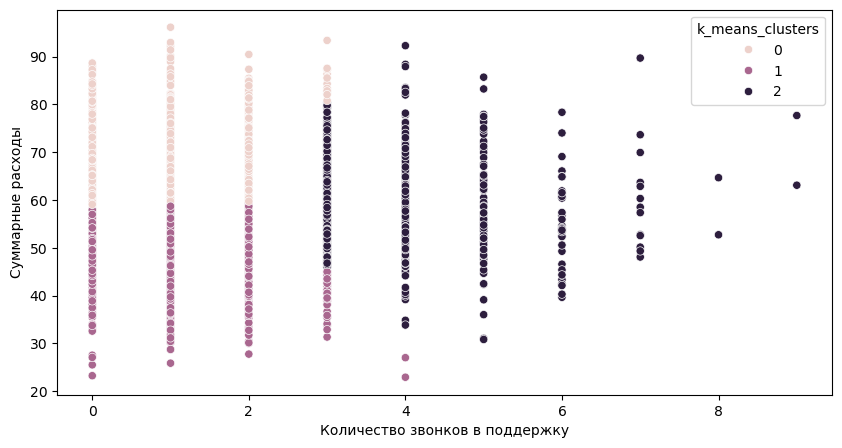

In [70]:
plot_clusters(df, "k_means_clusters")

### Агломеративная кластеризация

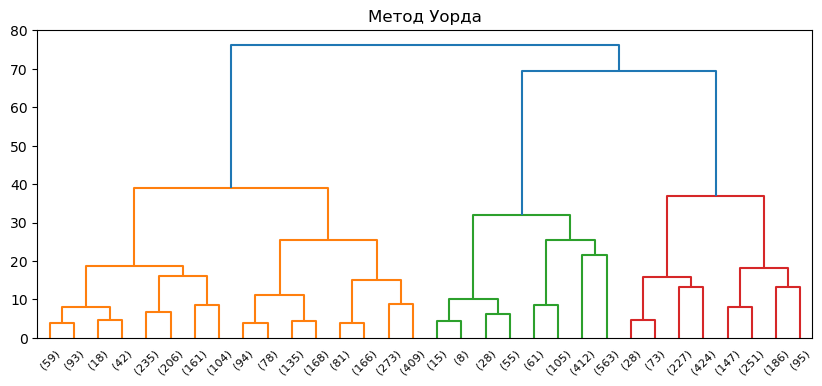

In [75]:
Y = linkage(X_scaled, "ward")
fig, ax = plt.subplots(figsize = (10,4))
plt.title("Метод Уорда")
dendr = dendrogram(Y, p = 4, truncate_mode = "level", orientation = 'top')
plt.show()

In [76]:
n_clust = len(set(dendr['leaves_color_list']))
print("Рекомендуемое количество кластеров : ", n_clust)

Рекомендуемое количество кластеров :  3


In [77]:
hclust = AgglomerativeClustering(n_clusters = n_clust, linkage = 'ward').fit(X_scaled)
df["hclust_clusters"] = hclust.labels_

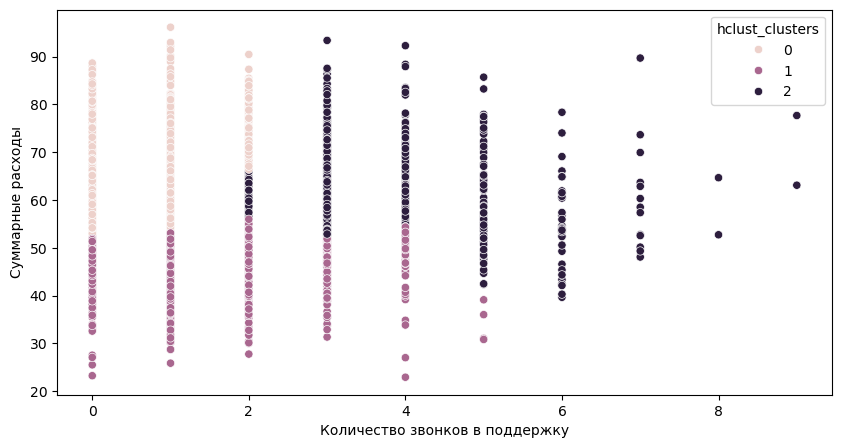

In [78]:
plot_clusters(df, "hclust_clusters")

### DBSCAN

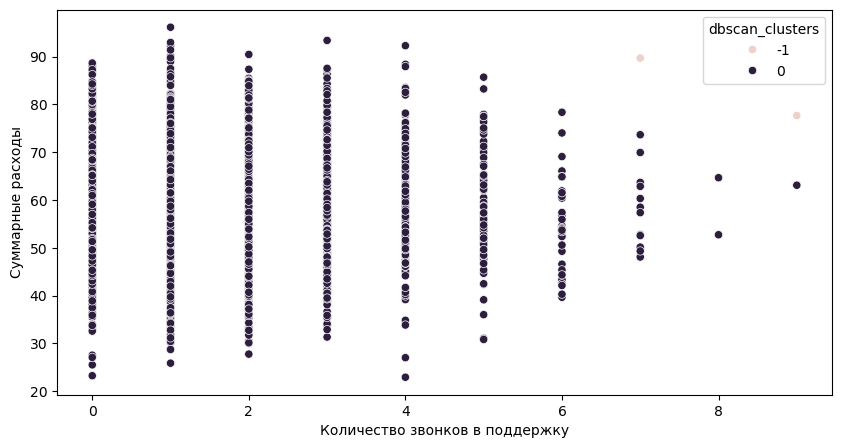

In [86]:
dbsc = DBSCAN(eps = 0.79, min_samples = 2).fit(X_scaled)
df["dbscan_clusters"] = dbsc.labels_
plot_clusters(df, "dbscan_clusters")